# **Energy Demand Forecasting - EDA**


**Merged cleaned dataset:**

Merged Energy demand historical dataset:

merged_energy_demand_dataset.csv

(Source: From Datasets Cleaning process outputs, stored in github: https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main)



**Phase 1: Understanding the variables**

**Phase 2: Considering Calendar effects - immediate effect**

**Phase 3: Considering Weather relationships - immediate effect**

**Phase 4: Considering Economic indicators - trend / longer term effect**

**Phase 5: Considering COVID period - anomaly effect**

**Phase 6: Cross-predictor checks - check multi-linearity, correction & etc.**

**Phase 7: Feature engineering wrap-up**

**Phase 8: Dataset split - Train, Validation and Test**





In [1]:
# Read the cleaned dataset directly from GitHub (public repo, no auth needed);
# save this notebook's own outputs (figures + new processed data) to local Colab folders.
import os
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main"
PROCESSED_DIR = f"{BASE_URL}/data/processed"   # read: cleaned inputs from the cleaning notebook

LOCAL_PROCESSED_DIR = "data/processed"          # write: this notebook's own new processed outputs
OUTPUT_DIR = "outputs/eda"                      # write: all figures generated in this notebook

os.makedirs(LOCAL_PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# **Phase 1: Understanding the variables**



Shape: (5641, 13)

Date range: 2009-01-01 00:00:00 to 2024-06-11 00:00:00

NaN check:
 date                       0
nd_total_mwh               0
is_holiday                 0
min_temp °c                0
max_temp °c                0
rain mm                    0
humidity %                 0
cloud_cover %              0
wind_speed km/h            0
pmi                        0
rsi_mom_change             0
rsi_volume                 0
StringencyIndex_Average    0
dtype: int64

Duplicate dates: 0

Summary statistics:
                          count           mean            std            min  \
nd_total_mwh             5641.0  753088.737192  133760.637788  421444.500000   
is_holiday               5641.0       0.023046       0.150061       0.000000   
min_temp °c              5641.0       6.864821       4.585823      -8.049913   
max_temp °c              5641.0      13.343068       5.695703      -2.489953   
rain mm                  5641.0       2.308325       3.118245       0.000000   
hu

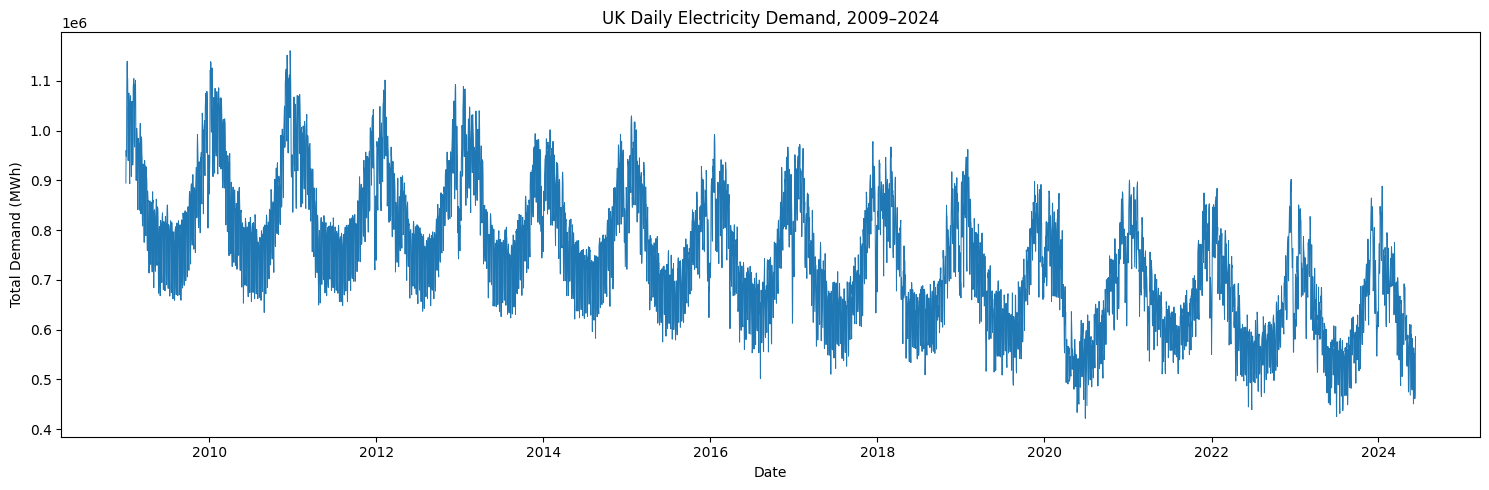

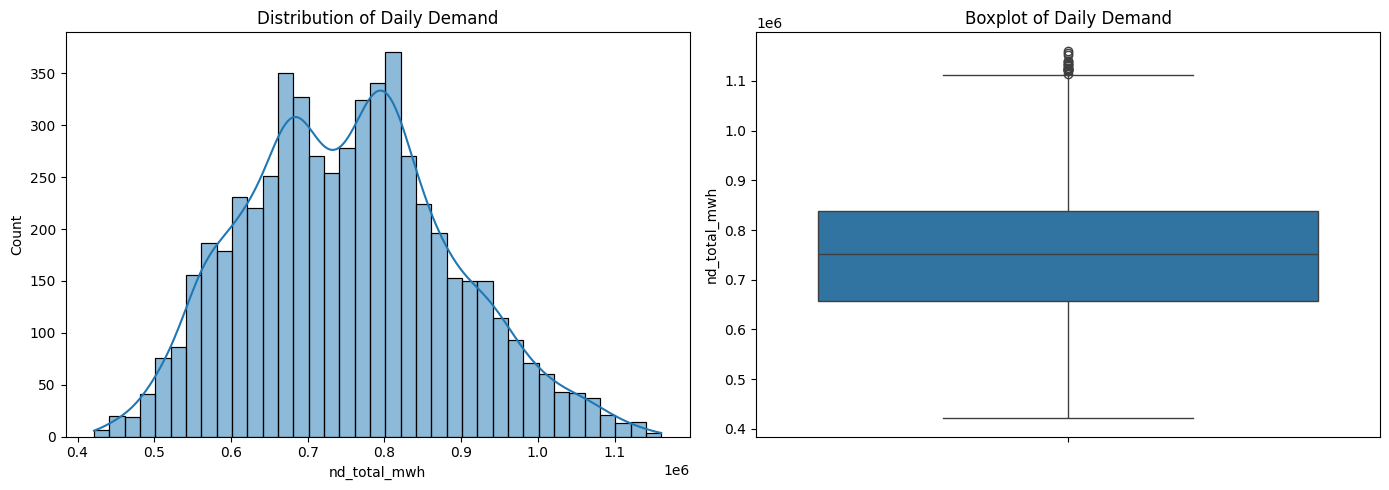

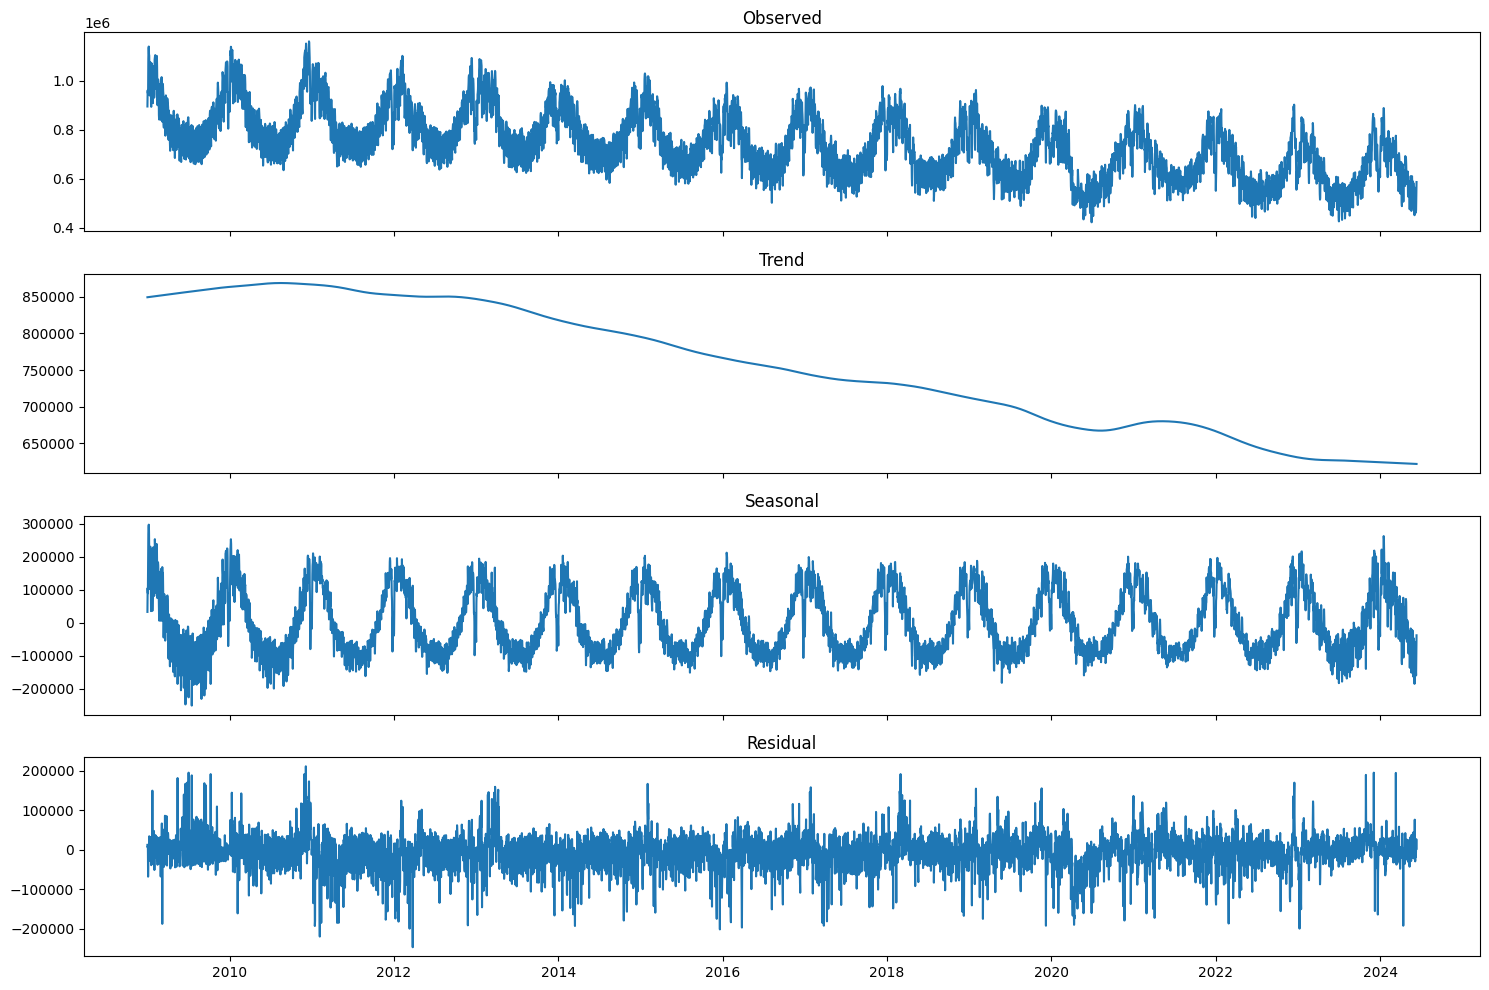


ADF Statistic: -3.4597
p-value: 0.0091
=> Stationary


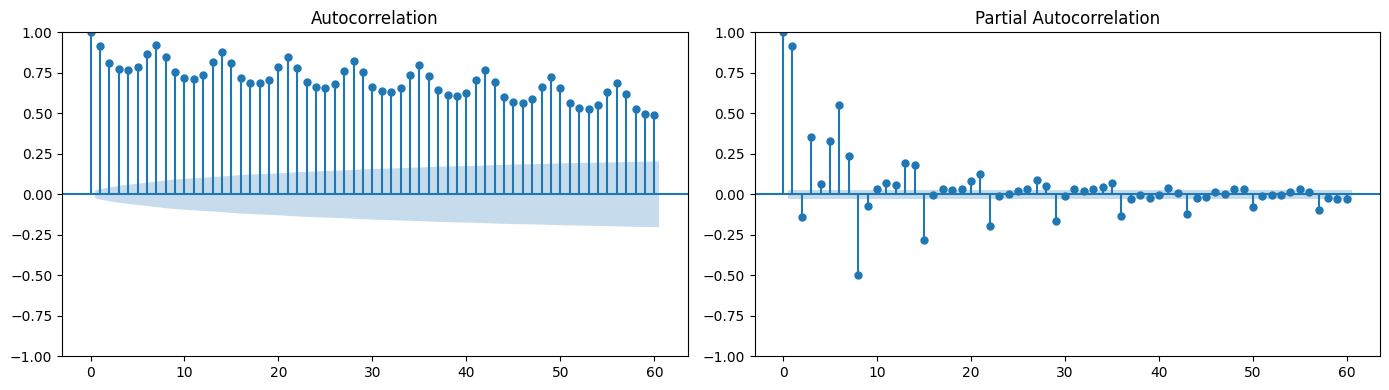

In [2]:
# Phase 1: Understanding the variables

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Load and final checkpoint
df = pd.read_csv(f'{PROCESSED_DIR}/merged_energy_demand_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print("Shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("\nNaN check:\n", df.isna().sum())
print("\nDuplicate dates:", df['date'].duplicated().sum())

df = df.set_index('date')

# 2. Describe all numeric columns
print("\nSummary statistics:")
print(df.describe().T)

# 3. Full demand time series plot
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['nd_total_mwh'], linewidth=0.7)
plt.title('UK Daily Electricity Demand, 2009–2024')
plt.xlabel('Date')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase1_demand_timeseries.png', dpi=150)
plt.show()

# 4. Distribution of demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['nd_total_mwh'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Daily Demand')
sns.boxplot(y=df['nd_total_mwh'], ax=axes[1])
axes[1].set_title('Boxplot of Daily Demand')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase1_demand_distribution.png', dpi=150)
plt.show()

# 5. STL decomposition (annual seasonality, period=365 for daily data)
stl = STL(df['nd_total_mwh'], period=365, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df.index, df['nd_total_mwh']); axes[0].set_title('Observed')
axes[1].plot(df.index, result.trend); axes[1].set_title('Trend')
axes[2].plot(df.index, result.seasonal); axes[2].set_title('Seasonal')
axes[3].plot(df.index, result.resid); axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase1_stl_decomposition.png', dpi=150)
plt.show()

# 6. ADF stationarity test
adf_result = adfuller(df['nd_total_mwh'])
print(f"\nADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("=> Stationary" if adf_result[1] < 0.05 else "=> Non-stationary")

# 7. ACF/PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['nd_total_mwh'], lags=60, ax=axes[0])
plot_pacf(df['nd_total_mwh'], lags=60, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase1_acf_pacf.png', dpi=150)
plt.show()

# **Phase 2: Considering Calendar effects - immediate effect**

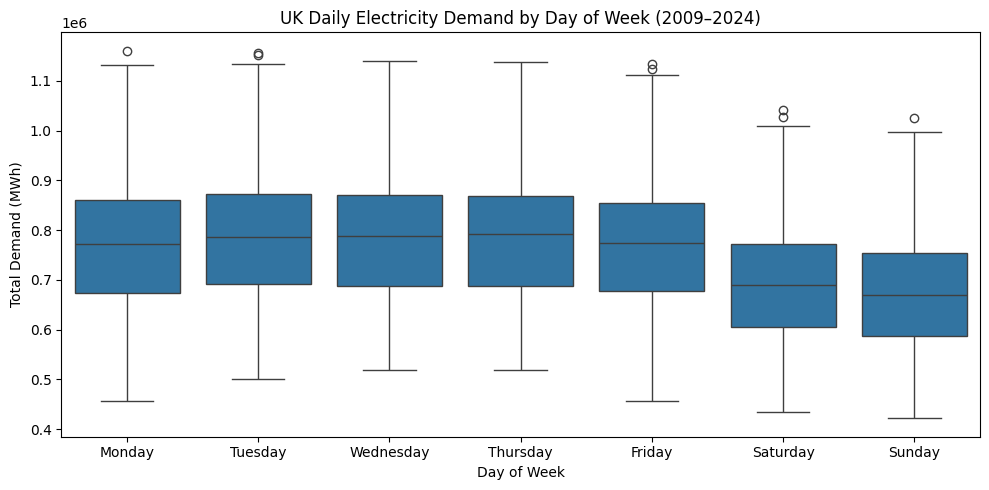

Weekday mean demand: 780,549 MWh
Weekend mean demand: 684,454 MWh
Weekend vs weekday difference: -12.31%

Welch's t-test (weekday vs weekend): t=26.803, p=4.441e-143
=> Statistically significant difference


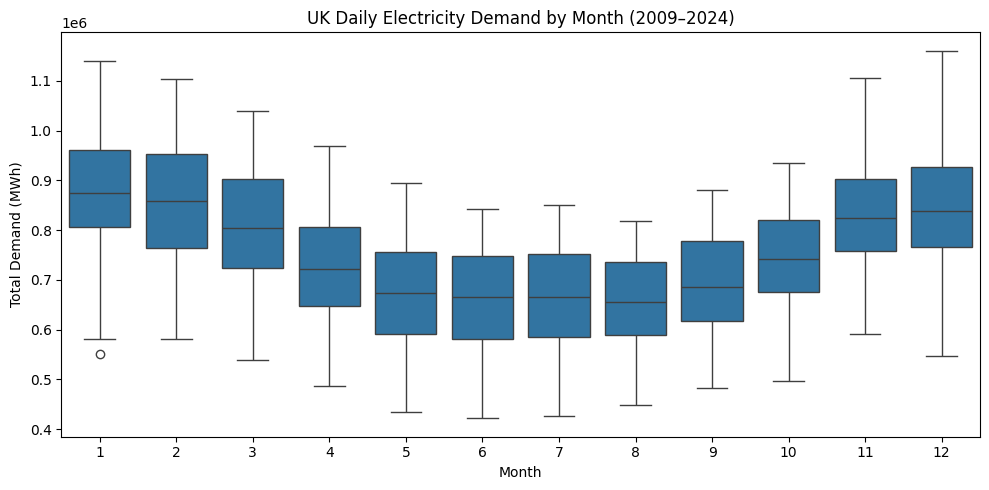


Holiday mean demand: 667,711 MWh
Non-holiday mean demand: 755,103 MWh
Holiday vs non-holiday difference: -11.57%


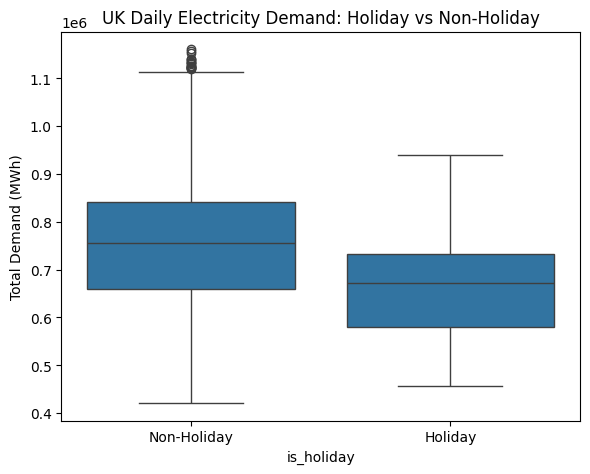


Welch's t-test (holiday vs non-holiday): t=-9.429, p=1.25e-16
=> Statistically significant difference
Weekday-only non-holiday mean: 784,190 MWh
Weekday-only holiday mean: 666,858 MWh
Holiday effect (isolated from weekend effect): -14.96%
t=-12.499, p=2.162e-24


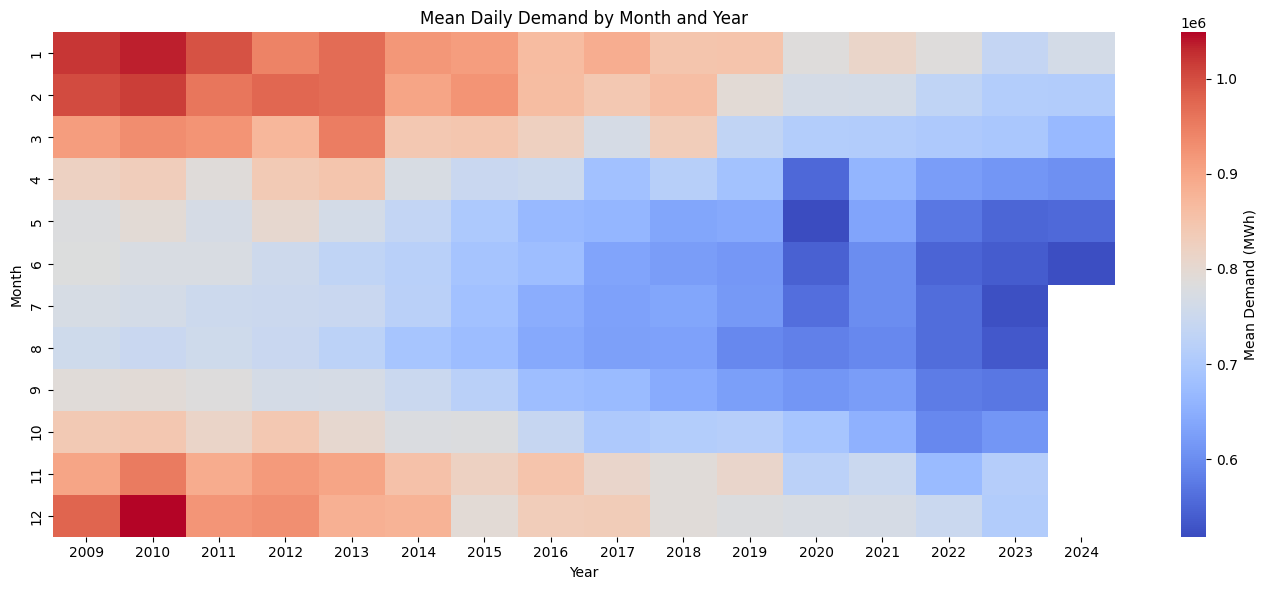

In [3]:
# Phase 2: Considering Calendar effects - immediate effect

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Build calendar features from the date index
df['day_of_week'] = df.index.dayofweek          # 0=Monday ... 6=Sunday
df['day_name'] = df.index.day_name()
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df.index.month
df['year'] = df.index.year

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Demand by day of week
plt.figure(figsize=(10, 5))
sns.boxplot(x='day_name', y='nd_total_mwh', data=df, order=day_order)
plt.title('UK Daily Electricity Demand by Day of Week (2009–2024)')
plt.xlabel('Day of Week')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase2_demand_by_dow.png', dpi=150)
plt.show()

# 3. Weekday vs weekend comparison
weekday_mean = df.loc[df['is_weekend'] == 0, 'nd_total_mwh'].mean()
weekend_mean = df.loc[df['is_weekend'] == 1, 'nd_total_mwh'].mean()
pct_diff = (weekend_mean - weekday_mean) / weekday_mean * 100

print(f"Weekday mean demand: {weekday_mean:,.0f} MWh")
print(f"Weekend mean demand: {weekend_mean:,.0f} MWh")
print(f"Weekend vs weekday difference: {pct_diff:.2f}%")

# Statistical test: is the weekday/weekend difference significant?
weekday_vals = df.loc[df['is_weekend'] == 0, 'nd_total_mwh']
weekend_vals = df.loc[df['is_weekend'] == 1, 'nd_total_mwh']
t_stat, p_val = stats.ttest_ind(weekday_vals, weekend_vals, equal_var=False)
print(f"\nWelch's t-test (weekday vs weekend): t={t_stat:.3f}, p={p_val:.4g}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No significant difference")

# 4. Demand by month (captures part of the annual seasonality already seen in STL, but at calendar granularity)
plt.figure(figsize=(10, 5))
sns.boxplot(x='month', y='nd_total_mwh', data=df)
plt.title('UK Daily Electricity Demand by Month (2009–2024)')
plt.xlabel('Month')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase2_demand_by_month.png', dpi=150)
plt.show()

# 5. Holiday vs non-holiday comparison
holiday_mean = df.loc[df['is_holiday'] == 1, 'nd_total_mwh'].mean()
non_holiday_mean = df.loc[df['is_holiday'] == 0, 'nd_total_mwh'].mean()
holiday_pct_diff = (holiday_mean - non_holiday_mean) / non_holiday_mean * 100

print(f"\nHoliday mean demand: {holiday_mean:,.0f} MWh")
print(f"Non-holiday mean demand: {non_holiday_mean:,.0f} MWh")
print(f"Holiday vs non-holiday difference: {holiday_pct_diff:.2f}%")

plt.figure(figsize=(6, 5))
sns.boxplot(x='is_holiday', y='nd_total_mwh', data=df)
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.title('UK Daily Electricity Demand: Holiday vs Non-Holiday')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase2_demand_holiday.png', dpi=150)
plt.show()

holiday_vals = df.loc[df['is_holiday'] == 1, 'nd_total_mwh']
non_holiday_vals = df.loc[df['is_holiday'] == 0, 'nd_total_mwh']
t_stat_h, p_val_h = stats.ttest_ind(holiday_vals, non_holiday_vals, equal_var=False)
print(f"\nWelch's t-test (holiday vs non-holiday): t={t_stat_h:.3f}, p={p_val_h:.4g}")
print("=> Statistically significant difference" if p_val_h < 0.05 else "=> No significant difference")

# Isolate the holiday effect from weekday-only baseline (excludes weekends from the comparison)
weekday_non_holiday = df.loc[(df['is_weekend'] == 0) & (df['is_holiday'] == 0), 'nd_total_mwh']
weekday_holiday = df.loc[(df['is_weekend'] == 0) & (df['is_holiday'] == 1), 'nd_total_mwh']

pct_diff_clean = (weekday_holiday.mean() - weekday_non_holiday.mean()) / weekday_non_holiday.mean() * 100
t_stat_clean, p_val_clean = stats.ttest_ind(weekday_holiday, weekday_non_holiday, equal_var=False)

print(f"Weekday-only non-holiday mean: {weekday_non_holiday.mean():,.0f} MWh")
print(f"Weekday-only holiday mean: {weekday_holiday.mean():,.0f} MWh")
print(f"Holiday effect (isolated from weekend effect): {pct_diff_clean:.2f}%")
print(f"t={t_stat_clean:.3f}, p={p_val_clean:.4g}")


# 6. Heatmap: average demand by month x year, to visually separate calendar seasonality from the long-term trend
pivot = df.pivot_table(values='nd_total_mwh', index='month', columns='year', aggfunc='mean')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='coolwarm', annot=False, cbar_kws={'label': 'Mean Demand (MWh)'})
plt.title('Mean Daily Demand by Month and Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase2_month_year_heatmap.png', dpi=150)
plt.show()

# **Phase 3: Considering Weather relationships - immediate effect**


Linear (Pearson) correlation with demand:
max_temp °c       -0.649047
min_temp °c       -0.627824
rain mm           -0.030071
wind_speed km/h    0.062089
cloud_cover %      0.073181
humidity %         0.546981
Name: nd_total_mwh, dtype: float64


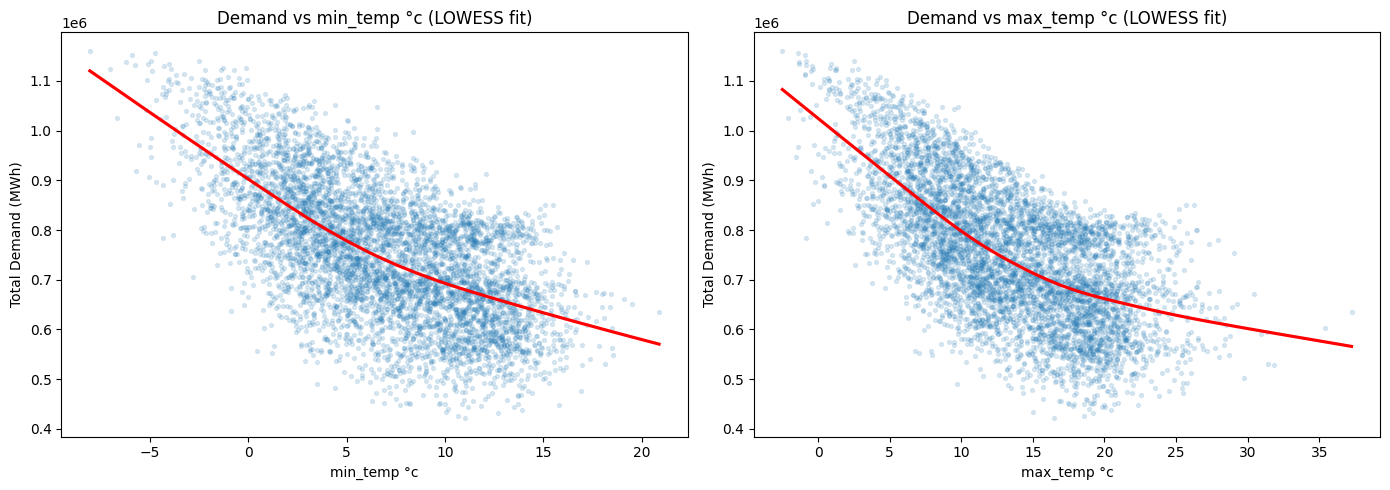


HDD summary:
count    5641.000000
mean        3.598152
std         3.974224
min         0.000000
25%         0.000000
50%         2.318194
75%         6.520422
max        17.989953
Name: hdd, dtype: float64


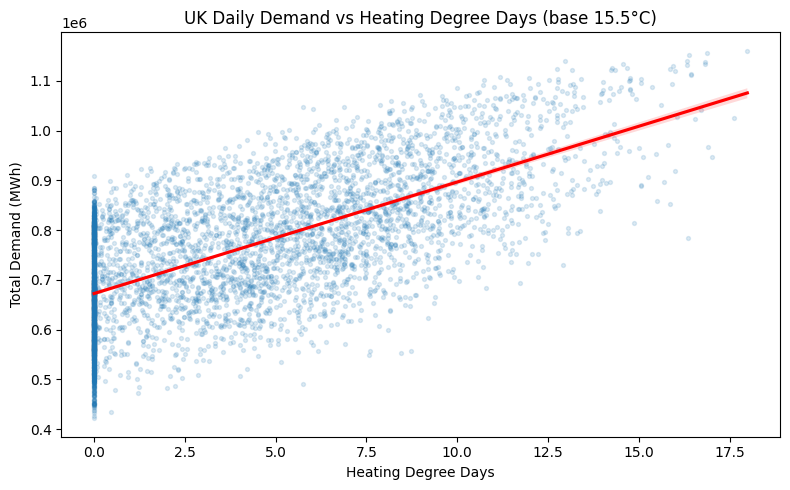


Correlation of demand with HDD: 0.666 (vs raw max_temp: -0.649)


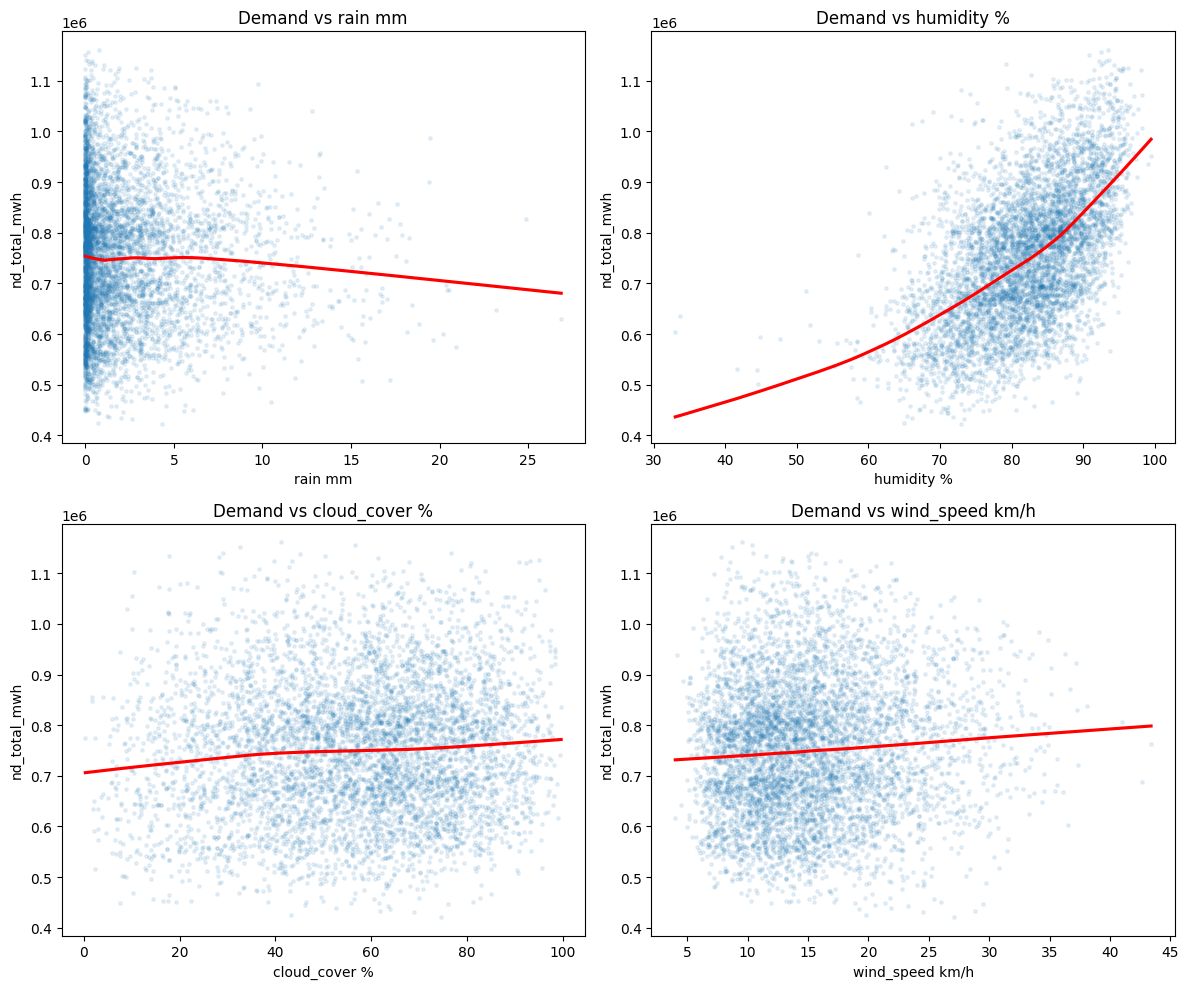

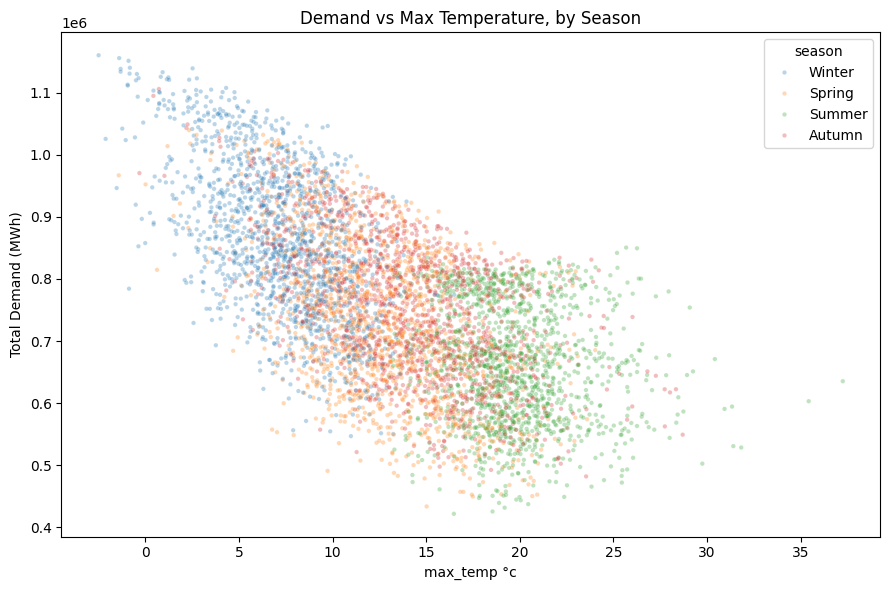


Correlation and linear slope of demand vs max_temp, by season:
  Winter: r=-0.561, slope=-22,187 MWh/°C, p=3.469e-118
  Spring: r=-0.491, slope=-15,957 MWh/°C, p=4.484e-90
  Summer: r=-0.136, slope=-4,239 MWh/°C, p=3.552e-07
  Autumn: r=-0.557, slope=-14,395 MWh/°C, p=6.903e-112


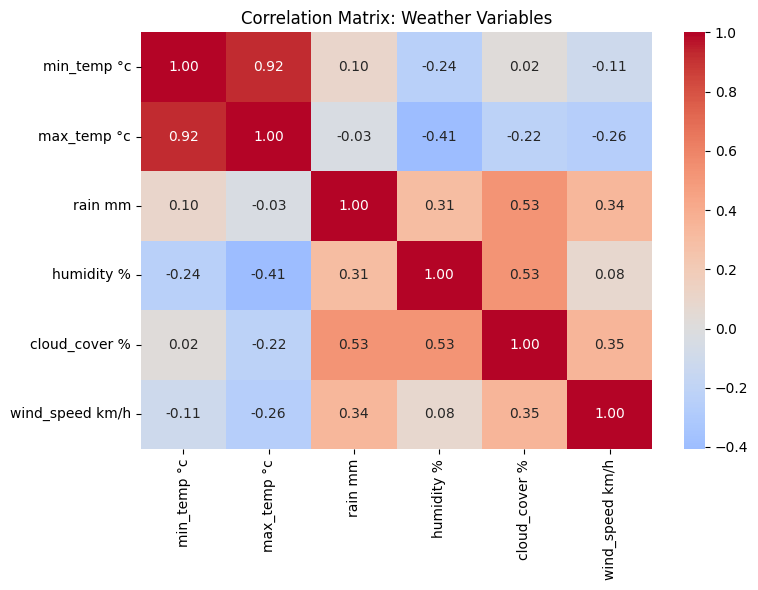

In [4]:
# Phase 3: Considering Weather relationships - immediate effect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

weather_cols = ['min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h']

# 1. Correlation of demand with each weather variable (linear check)
corr_table = df[['nd_total_mwh'] + weather_cols].corr()['nd_total_mwh'].drop('nd_total_mwh')
print("Linear (Pearson) correlation with demand:")
print(corr_table.sort_values())

# 2. Scatter + LOWESS smoother for temperature (to check for non-linearity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['min_temp °c', 'max_temp °c']):
    sns.regplot(x=df[col], y=df['nd_total_mwh'], ax=ax, scatter_kws={'alpha': 0.15, 's': 8},
                lowess=True, line_kws={'color': 'red'})
    ax.set_title(f'Demand vs {col} (LOWESS fit)')
    ax.set_ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_temp_scatter_lowess.png', dpi=150)
plt.show()

# 3. Heating Degree Days (HDD) - captures the non-linear "heating-dominated" relationship
# Base temperature of 15.5 C is the standard UK convention (Met Office / degree-day industry standard)
base_temp = 15.5
df['hdd'] = (base_temp - df['max_temp °c']).clip(lower=0)

print(f"\nHDD summary:\n{df['hdd'].describe()}")

plt.figure(figsize=(8, 5))
sns.regplot(x=df['hdd'], y=df['nd_total_mwh'], scatter_kws={'alpha': 0.15, 's': 8},
            line_kws={'color': 'red'})
plt.title('UK Daily Demand vs Heating Degree Days (base 15.5°C)')
plt.xlabel('Heating Degree Days')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_hdd_scatter.png', dpi=150)
plt.show()

hdd_corr = df[['nd_total_mwh', 'hdd']].corr().iloc[0, 1]
print(f"\nCorrelation of demand with HDD: {hdd_corr:.3f} (vs raw max_temp: {corr_table['max_temp °c']:.3f})")

# 4. Remaining weather variables: rain, humidity, cloud cover, wind speed
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
remaining_cols = ['rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h']
for ax, col in zip(axes.flat, remaining_cols):
    sns.regplot(x=df[col], y=df['nd_total_mwh'], ax=ax, scatter_kws={'alpha': 0.1, 's': 6},
                lowess=True, line_kws={'color': 'red'})
    ax.set_title(f'Demand vs {col}')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_other_weather_scatter.png', dpi=150)
plt.show()

# 5. Seasonal split: does the temperature-demand relationship differ by season?
# (Expect a steeper negative slope in winter than in summer, given heating dominance)
df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})

plt.figure(figsize=(9, 6))
sns.scatterplot(x='max_temp °c', y='nd_total_mwh', hue='season', data=df, alpha=0.3, s=10,
                 hue_order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Demand vs Max Temperature, by Season')
plt.ylabel('Total Demand (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_temp_by_season.png', dpi=150)
plt.show()

# 6. Quantify per-season correlation and slope
print("\nCorrelation and linear slope of demand vs max_temp, by season:")
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    subset = df[df['season'] == season]
    r, p = stats.pearsonr(subset['max_temp °c'], subset['nd_total_mwh'])
    slope, intercept, _, _, _ = stats.linregress(subset['max_temp °c'], subset['nd_total_mwh'])
    print(f"  {season}: r={r:.3f}, slope={slope:,.0f} MWh/°C, p={p:.4g}")

# 7. Weather variable correlation matrix (check for multicollinearity among predictors themselves)
plt.figure(figsize=(8, 6))
sns.heatmap(df[weather_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Weather Variables')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase3_weather_intercorrelation.png', dpi=150)
plt.show()

In [5]:
# Check whether humidity's correlation with demand survives controlling for temperature (partial correlation)

!pip install pingouin -q

import pingouin as pg  # !pip install pingouin if not already available

partial_corr = pg.partial_corr(data=df, x='humidity %', y='nd_total_mwh', covar='max_temp °c')
print(partial_corr)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.8 MB/s eta 0:00:00
            n         r          CI95          p_val
pearson  5641  0.406776  [0.38, 0.43]  9.263528e-224


# **Phase 4: Considering Economic indicators - trend / longer term effect**

Monthly aggregated shape: (186, 6)
            nd_total_mwh          trend   pmi  pmi_mom_change  rsi_mom_change  \
date                                                                            
2009-01-01  1.019983e+06  850166.109926  34.9             0.0             0.8   
2009-02-01  1.001310e+06  851379.930397  35.8             0.9            -2.0   
2009-03-01  9.116016e+05  852582.419917  34.7            -1.1             0.5   
2009-04-01  8.218569e+05  853815.738195  39.5             4.8             0.5   
2009-05-01  7.812430e+05  855040.598108  43.1             3.6             0.1   

            rsi_volume  
date                    
2009-01-01        87.1  
2009-02-01        85.4  
2009-03-01        85.8  
2009-04-01        86.2  
2009-05-01        86.3  


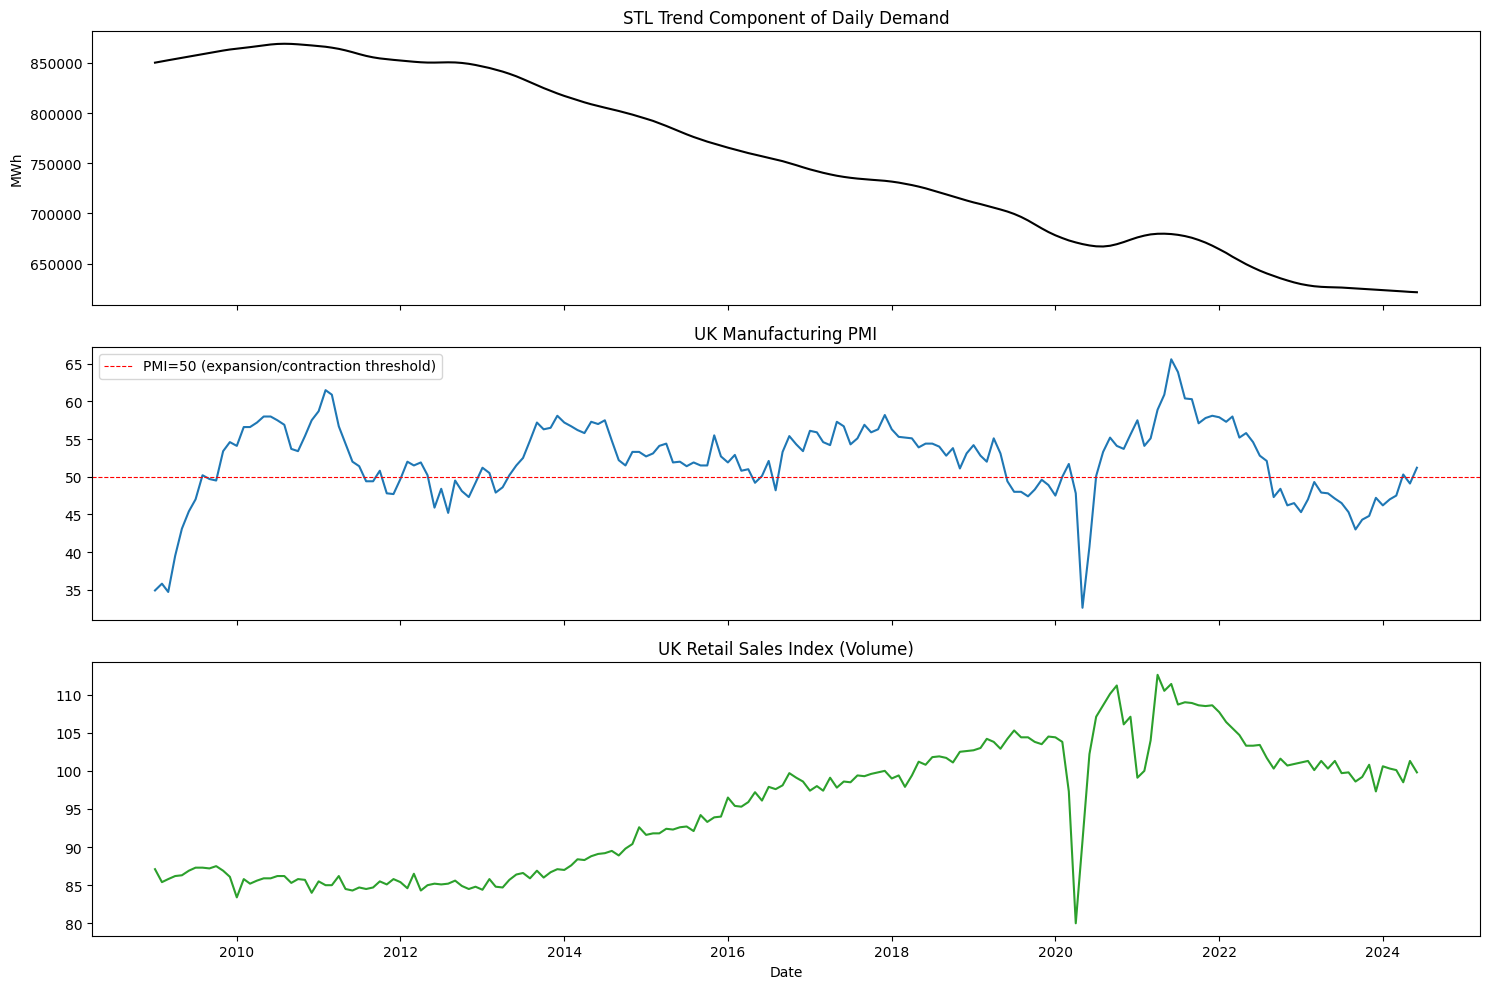


Correlation of STL trend component with economic indicators (monthly):
rsi_volume       -0.872936
rsi_mom_change    0.008233
pmi_mom_change    0.054255
pmi               0.071101
Name: trend, dtype: float64

For comparison — naive correlation using raw daily demand (same monthly value repeated ~30x):
rsi_volume       -0.542826
rsi_mom_change   -0.075333
pmi_mom_change    0.005859
pmi               0.071122
Name: nd_total_mwh, dtype: float64


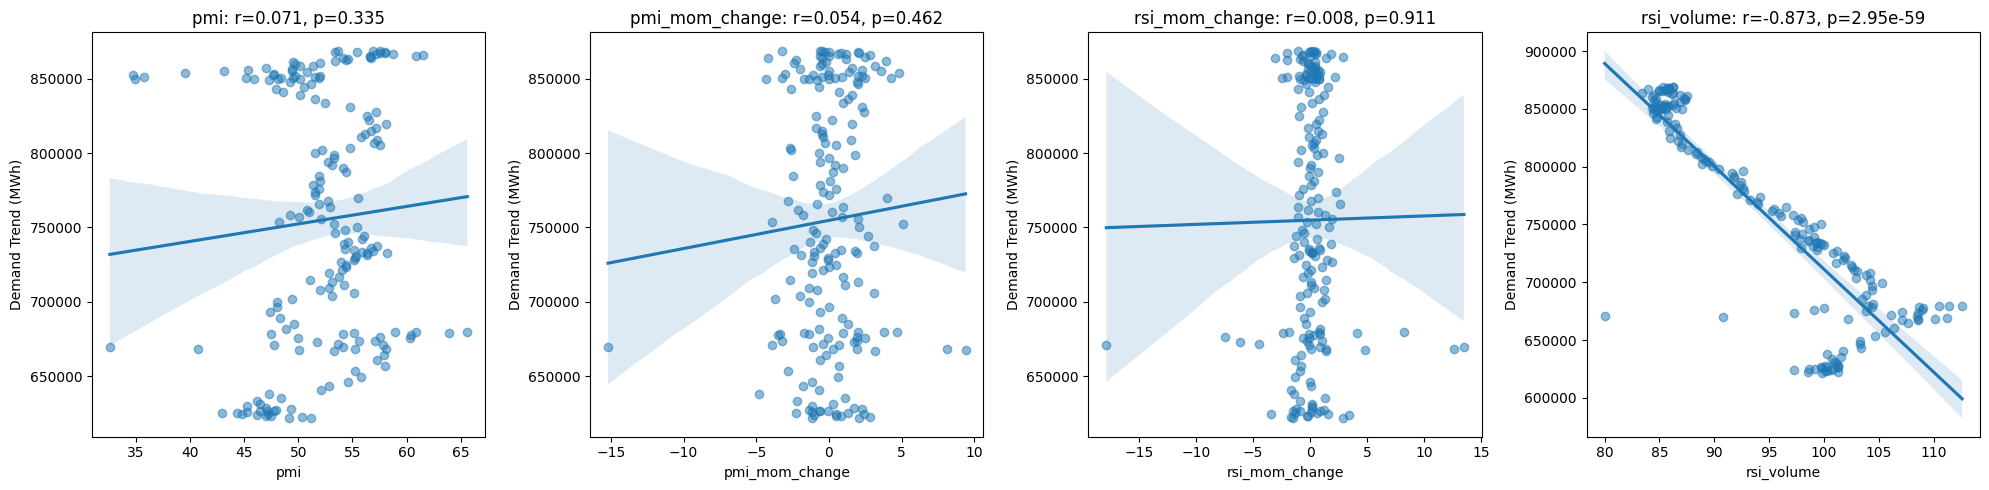

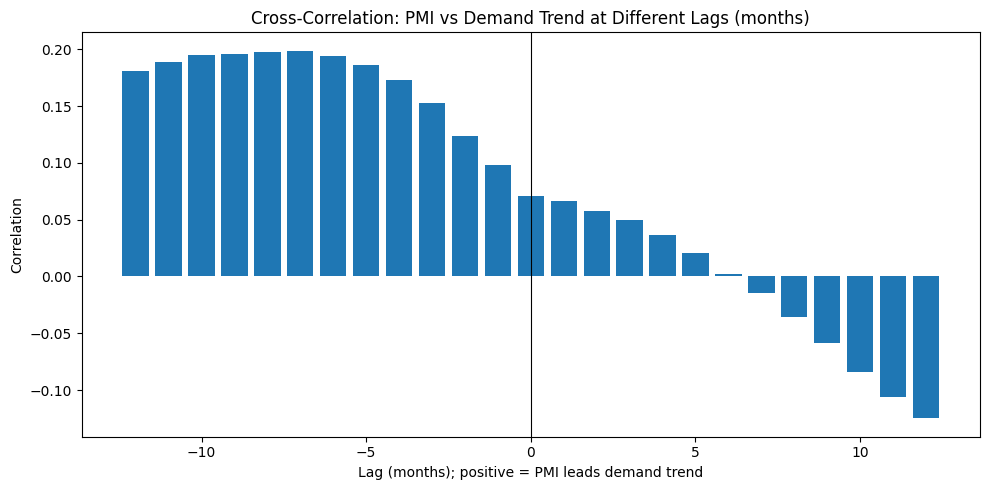


Strongest PMI-trend correlation at lag=-7 months: r=0.199, p=0.00762


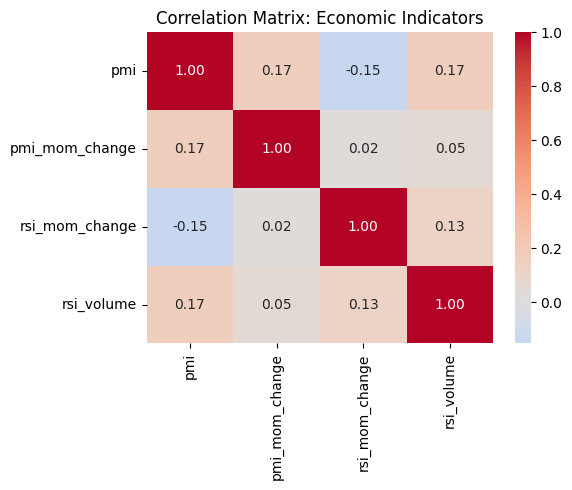

In [6]:
# Phase 4: Considering Economic indicators - trend / longer term effect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Attach the STL trend component (computed in Phase 1) to the dataframe
df['trend'] = result.trend

# 1b. Derive PMI's month-on-month change (RSI has this natively; PMI's source only gives the level)
# Note: unlike RSI (a sales volume, where % change is standard), PMI is already a diffusion
# index centred on 50 — economists conventionally discuss PMI moves in POINTS, not percent.
# Using .diff() here rather than .pct_change() for that reason.
df['pmi_mom_change'] = df['pmi'].diff()

# 2. Aggregate to monthly resolution. PMI/RSI are inherently monthly step-functions
#    (repeated ~30x across each month in the daily data), so comparing them directly
#    to raw daily demand inflates apparent correlation via autocorrelation.
#    Monthly aggregation, and comparing against the STL TREND (not raw demand),
#    is the fair test of a "longer-term structural" relationship.
monthly = df.resample('MS').agg(
    nd_total_mwh=('nd_total_mwh', 'mean'),
    trend=('trend', 'mean'),
    pmi=('pmi', 'first'),
    pmi_mom_change=('pmi_mom_change', 'first'),
    rsi_mom_change=('rsi_mom_change', 'first'),
    rsi_volume=('rsi_volume', 'first')
)

print("Monthly aggregated shape:", monthly.shape)
print(monthly.head())

# 3. Time series overlay: STL trend vs PMI and RSI volume over the full period
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(monthly.index, monthly['trend'], color='black')
axes[0].set_title('STL Trend Component of Daily Demand')
axes[0].set_ylabel('MWh')

axes[1].plot(monthly.index, monthly['pmi'], color='tab:blue')
axes[1].axhline(50, color='red', linestyle='--', linewidth=0.8, label='PMI=50 (expansion/contraction threshold)')
axes[1].set_title('UK Manufacturing PMI')
axes[1].legend()

axes[2].plot(monthly.index, monthly['rsi_volume'], color='tab:green')
axes[2].set_title('UK Retail Sales Index (Volume)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase4_trend_vs_economic_timeseries.png', dpi=150)
plt.show()

# 4. Correlation: demand TREND (not raw demand) vs economic indicators
econ_cols = ['pmi', 'pmi_mom_change', 'rsi_mom_change', 'rsi_volume']
trend_corr = monthly[['trend'] + econ_cols].corr()['trend'].drop('trend')
print("\nCorrelation of STL trend component with economic indicators (monthly):")
print(trend_corr.sort_values())

# 5. For comparison: naive correlation using raw daily values
#    (demonstrates the autocorrelation-inflation issue described above)
naive_corr = df[['nd_total_mwh'] + econ_cols].corr()['nd_total_mwh'].drop('nd_total_mwh')
print("\nFor comparison — naive correlation using raw daily demand (same monthly value repeated ~30x):")
print(naive_corr.sort_values())

# 6. Scatter plots: monthly trend vs each economic indicator
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, econ_cols):
    sns.regplot(x=monthly[col], y=monthly['trend'], ax=ax, scatter_kws={'alpha': 0.5})
    r, p = stats.pearsonr(monthly[col], monthly['trend'])
    ax.set_title(f'{col}: r={r:.3f}, p={p:.3g}')
    ax.set_ylabel('Demand Trend (MWh)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase4_trend_econ_scatter.png', dpi=150)
plt.show()

# 7. Cross-correlation at different lags — does PMI lead or lag the demand trend?
#    Positive lag = PMI from that many months earlier is compared to current trend
#    (i.e. testing whether PMI is a LEADING indicator of demand trend)
def lagged_corr(data, col_a, col_b, max_lag=12):
    results = []
    for lag in range(-max_lag, max_lag + 1):
        shifted = data[col_b].shift(lag)
        valid = data[[col_a]].join(shifted.rename('shifted')).dropna()
        r, p = stats.pearsonr(valid[col_a], valid['shifted'])
        results.append((lag, r, p))
    return pd.DataFrame(results, columns=['lag_months', 'correlation', 'p_value'])

lag_df = lagged_corr(monthly, 'trend', 'pmi', max_lag=12)
best_lag = lag_df.loc[lag_df['correlation'].abs().idxmax()]

plt.figure(figsize=(10, 5))
plt.bar(lag_df['lag_months'], lag_df['correlation'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Cross-Correlation: PMI vs Demand Trend at Different Lags (months)')
plt.xlabel('Lag (months); positive = PMI leads demand trend')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase4_pmi_lag_crosscorr.png', dpi=150)
plt.show()

print(f"\nStrongest PMI-trend correlation at lag={int(best_lag['lag_months'])} months: "
      f"r={best_lag['correlation']:.3f}, p={best_lag['p_value']:.4g}")

# 8. Multicollinearity check among the economic indicators themselves
plt.figure(figsize=(6, 5))
sns.heatmap(monthly[econ_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Economic Indicators')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase4_econ_intercorrelation.png', dpi=150)
plt.show()

In [7]:
# Check whether the strong rsi_volume-trend correlation survives differencing
# (tests for a genuine short-run relationship vs. two series that simply trend in opposite directions)

monthly_diff = monthly[['trend', 'rsi_volume']].diff().dropna()
r_diff, p_diff = stats.pearsonr(monthly_diff['trend'], monthly_diff['rsi_volume'])
print(f"Correlation of MONTHLY CHANGES in trend vs rsi_volume: r={r_diff:.3f}, p={p_diff:.4g}")
print(f"(Compare to level correlation: r=-0.873)")

Correlation of MONTHLY CHANGES in trend vs rsi_volume: r=0.015, p=0.8355
(Compare to level correlation: r=-0.873)


# **Phase 5: Considering COVID-19 Period - anomaly effect**

Days with stringency data tracked (2020-2022): 1096
Days with StringencyIndex_Average > 0: 1077


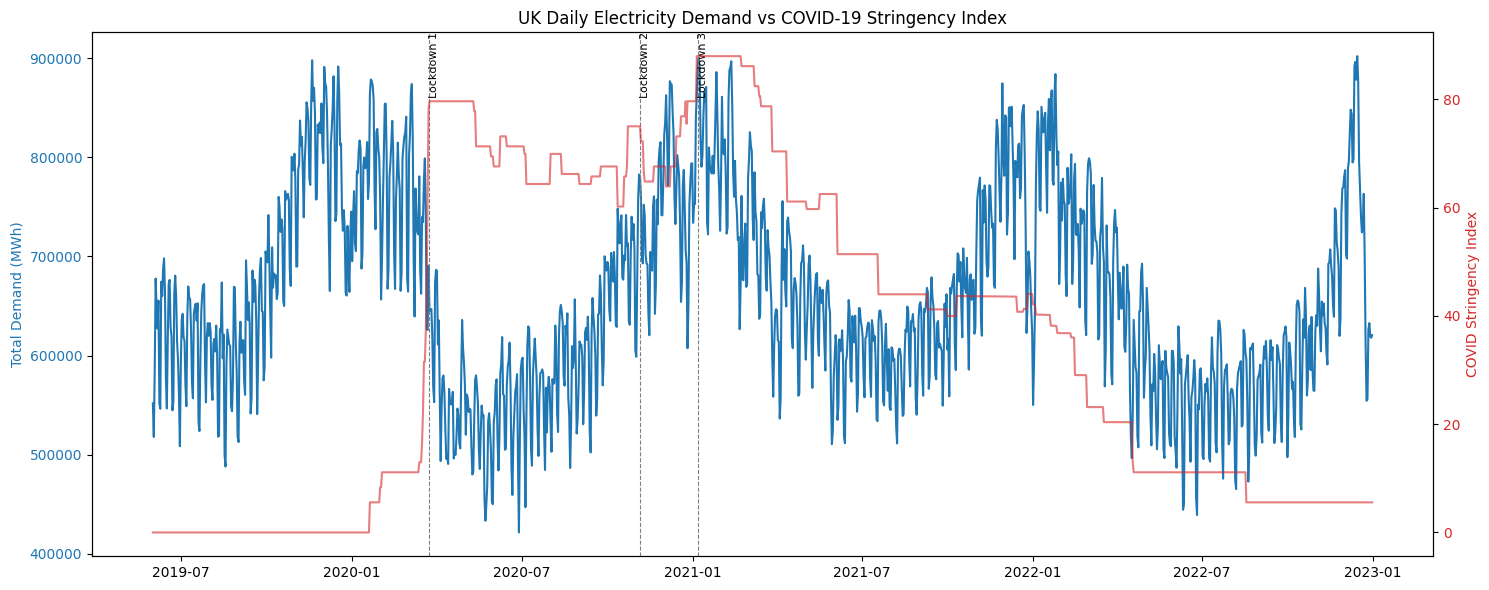


Naive correlation (demand vs stringency, within tracked window): r=0.040, p=0.1874
Partial correlation (demand vs stringency, controlling for HDD): r=-0.073, p=0.01593


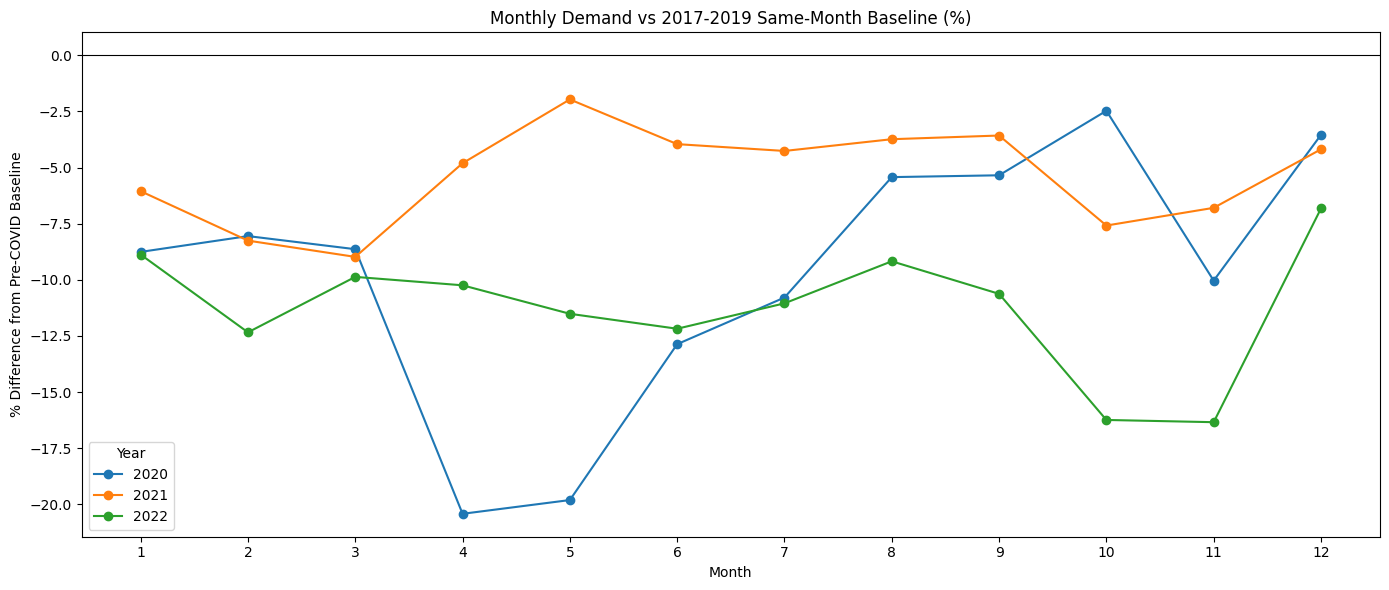


Monthly % difference from pre-COVID (2017-2019) baseline:
 year  month  pct_vs_baseline
 2020      1            -8.76
 2020      2            -8.05
 2020      3            -8.64
 2020      4           -20.42
 2020      5           -19.81
 2020      6           -12.87
 2020      7           -10.79
 2020      8            -5.43
 2020      9            -5.34
 2020     10            -2.47
 2020     11           -10.04
 2020     12            -3.54
 2021      1            -6.05
 2021      2            -8.25
 2021      3            -8.98
 2021      4            -4.81
 2021      5            -1.97
 2021      6            -3.96
 2021      7            -4.26
 2021      8            -3.74
 2021      9            -3.57
 2021     10            -7.58
 2021     11            -6.79
 2021     12            -4.19
 2022      1            -8.88
 2022      2           -12.34
 2022      3            -9.87
 2022      4           -10.24
 2022      5           -11.51
 2022      6           -12.18
 2022      

In [8]:
# Phase 5: Considering COVID-19 Period - anomaly effect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Define the COVID-tracked window (OxCGRT coverage: 2020-01-01 to 2022-12-31; 0 elsewhere)
df['is_covid_tracked'] = (df.index >= '2020-01-01') & (df.index <= '2022-12-31')
print(f"Days with stringency data tracked (2020-2022): {df['is_covid_tracked'].sum()}")
print(f"Days with StringencyIndex_Average > 0: {(df['StringencyIndex_Average'] > 0).sum()}")

# 2. Time series: demand vs stringency index over the COVID window, twin axis, with lockdown markers
covid_window = df.loc['2019-06-01':'2022-12-31']

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(covid_window.index, covid_window['nd_total_mwh'], color='tab:blue', label='Daily Demand')
ax1.set_ylabel('Total Demand (MWh)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(covid_window.index, covid_window['StringencyIndex_Average'], color='tab:red', alpha=0.6)
ax2.set_ylabel('COVID Stringency Index', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

for date, label in [('2020-03-23', 'Lockdown 1'), ('2020-11-05', 'Lockdown 2'), ('2021-01-06', 'Lockdown 3')]:
    ax1.axvline(pd.Timestamp(date), color='gray', linestyle='--', linewidth=0.8)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1], label, rotation=90, fontsize=8, va='top')

plt.title('UK Daily Electricity Demand vs COVID-19 Stringency Index')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase5_demand_stringency_overlay.png', dpi=150)
plt.show()

# 3. Naive correlation: demand vs stringency, within the tracked window only
tracked = df.loc[df['is_covid_tracked']]
r_naive, p_naive = stats.pearsonr(tracked['nd_total_mwh'], tracked['StringencyIndex_Average'])
print(f"\nNaive correlation (demand vs stringency, within tracked window): r={r_naive:.3f}, p={p_naive:.4g}")

# 4. Partial correlation controlling for HDD - lockdowns coincided with specific seasons,
#    so the raw correlation above risks confounding "COVID effect" with ordinary heating-season demand
def partial_corr_manual(data, x, y, control):
    slope_x, intercept_x, _, _, _ = stats.linregress(data[control], data[x])
    resid_x = data[x] - (slope_x * data[control] + intercept_x)
    slope_y, intercept_y, _, _, _ = stats.linregress(data[control], data[y])
    resid_y = data[y] - (slope_y * data[control] + intercept_y)
    return stats.pearsonr(resid_x, resid_y)

r_partial, p_partial = partial_corr_manual(tracked, 'StringencyIndex_Average', 'nd_total_mwh', 'hdd')
print(f"Partial correlation (demand vs stringency, controlling for HDD): r={r_partial:.3f}, p={p_partial:.4g}")

# 5. Year-over-year: each COVID-era month vs the average of the SAME calendar month
#    in the 3 preceding pre-COVID years - isolates the pandemic anomaly from normal seasonality
monthly_mean = df.groupby([df.index.year, df.index.month])['nd_total_mwh'].mean()
monthly_mean.index.names = ['year', 'month']
monthly_mean = monthly_mean.reset_index()

def pre_covid_baseline(month, years=(2017, 2018, 2019)):
    vals = monthly_mean.loc[(monthly_mean['month'] == month) & (monthly_mean['year'].isin(years)), 'nd_total_mwh']
    return vals.mean()

monthly_mean['baseline'] = monthly_mean['month'].apply(pre_covid_baseline)
monthly_mean['pct_vs_baseline'] = (monthly_mean['nd_total_mwh'] - monthly_mean['baseline']) / monthly_mean['baseline'] * 100
covid_period = monthly_mean[(monthly_mean['year'] >= 2020) & (monthly_mean['year'] <= 2022)]

plt.figure(figsize=(14, 6))
for yr in [2020, 2021, 2022]:
    subset = covid_period[covid_period['year'] == yr]
    plt.plot(subset['month'], subset['pct_vs_baseline'], marker='o', label=str(yr))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Demand vs 2017-2019 Same-Month Baseline (%)')
plt.xlabel('Month')
plt.ylabel('% Difference from Pre-COVID Baseline')
plt.legend(title='Year')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase5_yoy_vs_baseline.png', dpi=150)
plt.show()

print("\nMonthly % difference from pre-COVID (2017-2019) baseline:")
print(covid_period[['year', 'month', 'pct_vs_baseline']].round(2).to_string(index=False))

# 6. Weekday-only comparison during peak lockdown vs the SAME calendar window pre-COVID
#    (controls for both season AND weekday-mix simultaneously - the cleanest single test)
lockdown1 = df.loc['2020-03-23':'2020-06-15']
pre_covid_marchjune = df.loc[(df.index.year.isin([2017, 2018, 2019])) &
                              (((df.index.month == 3) & (df.index.day >= 23)) |
                               (df.index.month.isin([4, 5])) |
                               ((df.index.month == 6) & (df.index.day <= 15)))]

lockdown1_weekday = lockdown1.loc[lockdown1['is_weekend'] == 0, 'nd_total_mwh']
pre_covid_weekday = pre_covid_marchjune.loc[pre_covid_marchjune['is_weekend'] == 0, 'nd_total_mwh']

t_stat, p_val = stats.ttest_ind(lockdown1_weekday, pre_covid_weekday, equal_var=False)
pct_diff = (lockdown1_weekday.mean() - pre_covid_weekday.mean()) / pre_covid_weekday.mean() * 100

print(f"\nFirst lockdown weekday demand (23 Mar - 15 Jun 2020): {lockdown1_weekday.mean():,.0f} MWh")
print(f"Pre-COVID weekday demand (same calendar window, 2017-2019 avg): {pre_covid_weekday.mean():,.0f} MWh")
print(f"Difference: {pct_diff:.2f}%, t={t_stat:.3f}, p={p_val:.4g}")

# **Phase 6: Cross-Predictor Multicollinearity Check**

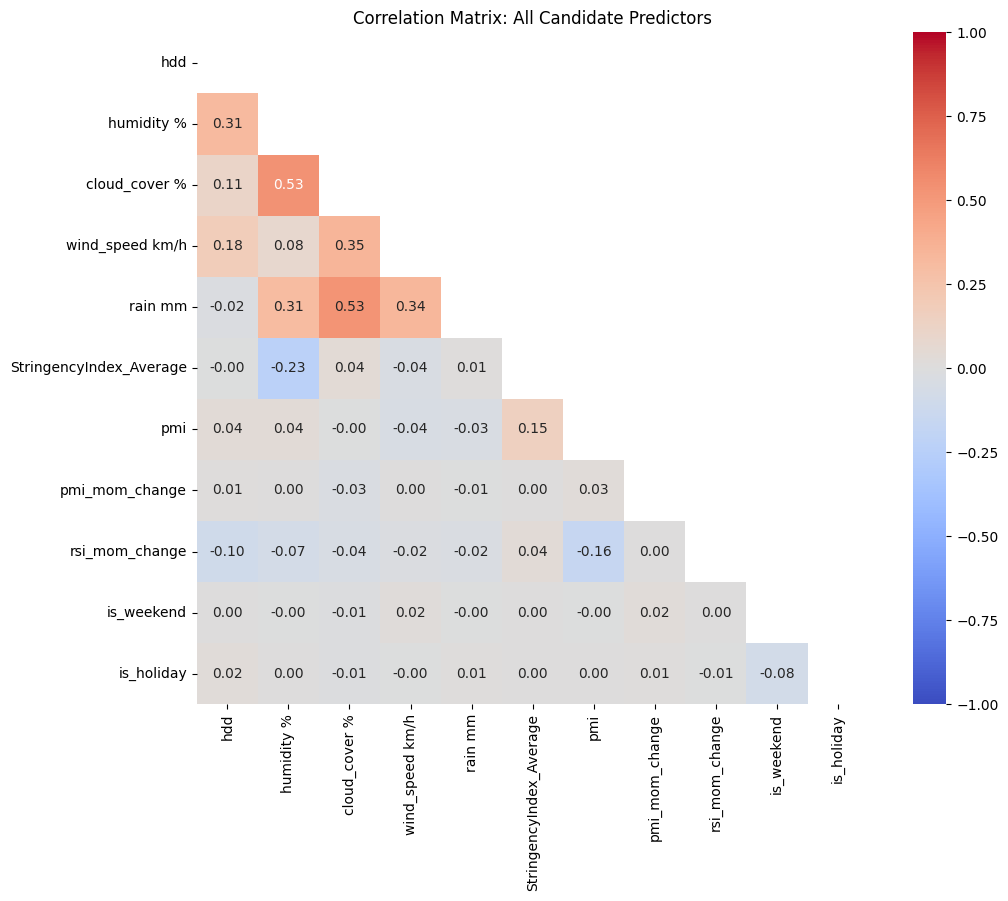

Variance Inflation Factors:
                feature      VIF
          cloud_cover % 1.974316
             humidity % 1.819059
                rain mm 1.490603
        wind_speed km/h 1.295357
                    hdd 1.217636
StringencyIndex_Average 1.164420
                    pmi 1.064811
         rsi_mom_change 1.040524
             is_holiday 1.008551
             is_weekend 1.008424
         pmi_mom_change 1.003344

Features with VIF > 5 (moderate concern):
None
Features with VIF > 10 (serious concern):
None

humidity % vs cloud_cover %: r=0.532, p=0

--- One-way ANOVA: hdd across month groups ---
F=1235.04, p=0  (significant grouping = month already captures much of hdd's seasonal signal)

--- One-way ANOVA: hdd across day_of_week groups ---
F=0.08, p=0.9977  (significant grouping = day_of_week already captures much of hdd's seasonal signal)


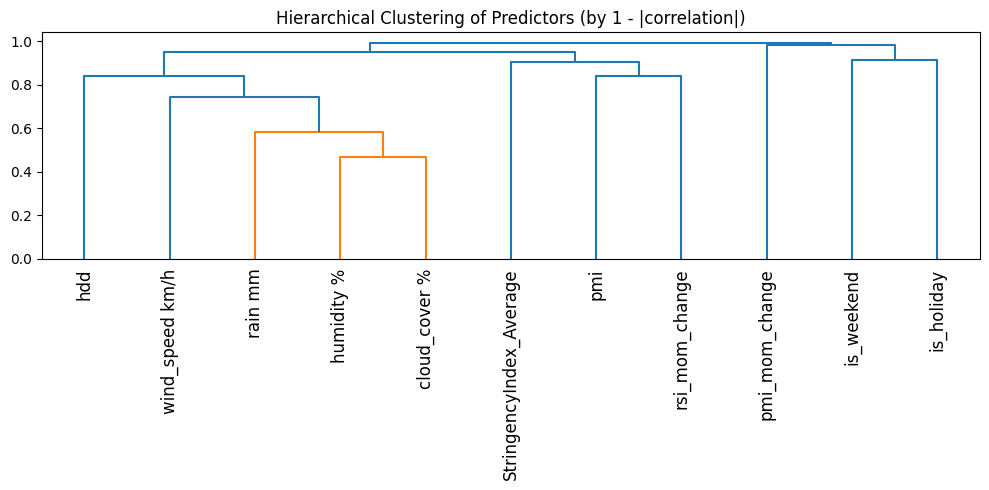

In [9]:
# Phase 6: Cross-Predictor Multicollinearity Check

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Assemble the full candidate continuous/binary predictor set
#    (categorical calendar features - month, day_of_week - are checked separately in step 5,
#    since VIF is only meaningful for continuous/numeric-encoded predictors)
candidate_features = [
    'hdd', 'humidity %', 'cloud_cover %', 'wind_speed km/h', 'rain mm',
    'StringencyIndex_Average', 'pmi','pmi_mom_change', 'rsi_mom_change',
    'is_weekend', 'is_holiday'
]

X = df[candidate_features].dropna().copy()

# 2. Full correlation heatmap across all candidate predictors
plt.figure(figsize=(11, 9))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: All Candidate Predictors')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase6_full_predictor_correlation.png', dpi=150)
plt.show()

# 3. Variance Inflation Factor (VIF) - the standard multicollinearity diagnostic
#    VIF > 5 = moderate concern; VIF > 10 = serious concern (feature is largely explained by the others)
X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))
print("\nFeatures with VIF > 5 (moderate concern):")
print(vif_data[vif_data['VIF'] > 5]['feature'].tolist() or "None")
print("Features with VIF > 10 (serious concern):")
print(vif_data[vif_data['VIF'] > 10]['feature'].tolist() or "None")

# 4. Targeted check: humidity vs cloud_cover (flagged in Phase 3 as correlated at 0.53)
r_hum_cloud, p_hum_cloud = stats.pearsonr(df['humidity %'], df['cloud_cover %'])
print(f"\nhumidity % vs cloud_cover %: r={r_hum_cloud:.3f}, p={p_hum_cloud:.4g}")

# 5. Categorical calendar features vs continuous predictors: check via ANOVA / eta-squared
#    (do month or day_of_week already "contain" information that hdd/humidity would duplicate?)
from scipy.stats import f_oneway

for cat_col in ['month', 'day_of_week']:
    print(f"\n--- One-way ANOVA: hdd across {cat_col} groups ---")
    groups = [group['hdd'].values for _, group in df.groupby(cat_col)]
    f_stat, p_val = f_oneway(*groups)
    print(f"F={f_stat:.2f}, p={p_val:.4g}  (significant grouping = {cat_col} already captures much of hdd's seasonal signal)")

# 6. Hierarchical clustering of predictors (visual grouping of redundant features)
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

dist = 1 - corr_matrix.abs()
condensed_dist = squareform(dist, checks=False)
linkage = hierarchy.linkage(condensed_dist, method='average')

plt.figure(figsize=(10, 5))
hierarchy.dendrogram(linkage, labels=corr_matrix.columns.tolist(), leaf_rotation=90)
plt.title('Hierarchical Clustering of Predictors (by 1 - |correlation|)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase6_predictor_dendrogram.png', dpi=150)
plt.show()



**Summary of findings in Phase 6**

Keep - hdd, humidity %, is_weekend, is_holiday, month / day_of_week, StringencyIndex_Average

Keep and review in Phase 7 - cloud_cover %, wind_speed km/h, rain mm,

Drop - rsi_volume, rsi_mom_change, pmi, pmi_mom_change

# **Phase 7: Feature Engineering - Building the Model-Ready Dataset**

In [10]:
# Phase 7: Feature Engineering - Building the Model-Ready Dataset

import numpy as np
import pandas as pd

# 1. Start from a clean copy, drop features confirmed to have no robust relationship (Phase 6)
df_model = df.drop(columns=['pmi', 'pmi_mom_change', 'rsi_mom_change', 'rsi_volume']).copy()

# 2. Cyclical encoding for month and day_of_week
#    Raw integer encoding (1-12, 0-6) implies a false discontinuity between e.g. Dec(12) and Jan(1),
#    or Sunday(6) and Monday(0). Sin/cos encoding preserves the true cyclical distance.
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['day_of_week'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['day_of_week'] / 7)

# Drop the raw integer versions and the redundant day_name/season/year helper columns
# (year is intentionally dropped as a raw feature - it would let the model directly memorise
#  the declining trend rather than learning it from HDD/calendar/stringency; year is retained
#  implicitly through the trend/seasonal structure the model learns from other features)
df_model = df_model.drop(columns=['month', 'day_of_week', 'day_name', 'season'])

# 3. Lag and rolling-window features for demand itself
#    Standard for time-series forecasting: yesterday's demand and recent averages are typically
#    the single strongest predictors of today's demand, on top of the exogenous drivers above.
df_model['demand_lag_1'] = df_model['nd_total_mwh'].shift(1)
df_model['demand_lag_7'] = df_model['nd_total_mwh'].shift(7)       # same day, previous week
df_model['demand_roll_mean_7'] = df_model['nd_total_mwh'].shift(1).rolling(window=7).mean()
df_model['demand_roll_mean_30'] = df_model['nd_total_mwh'].shift(1).rolling(window=30).mean()
df_model['demand_roll_std_7'] = df_model['nd_total_mwh'].shift(1).rolling(window=7).std()

# 4. Interaction term: HDD x is_weekend
#    Motivated by Phase 3/2 findings - the heating effect and the weekday/weekend effect were
#    each shown to be large and independent; an interaction term lets the model capture whether
#    the heating response itself differs between working days and non-working days
#    (e.g. commercial heating load only responds to cold on working days).
df_model['hdd_x_weekend'] = df_model['hdd'] * df_model['is_weekend']

# Remove STL-derived and other non-feature columns (trend/year/is_covid_tracked)
# - 'trend' is the STL trend component, derived FROM the target itself (Phase 1) -> excluded as standard practice against target leakage
# - 'year' would let the model memorise the historical decline directly rather than learn it from HDD/calendar/stringency -> excluded
# - 'is_covid_tracked' is a redundant window-marker, already encoded by StringencyIndex_Average -> excluded
df_model = df_model.drop(columns=['trend', 'year', 'is_covid_tracked'])

print(f"Corrected shape after dropping leaked/redundant columns: {df_model.shape}")
print(f"\nFinal columns:\n{df_model.columns.tolist()}")

# 5. Drop rows with NaNs introduced by lag/rolling features (first 30 rows only)
rows_before = len(df_model)
df_model = df_model.dropna()
print(f"Dropped {rows_before - len(df_model)} rows due to lag/rolling window NaNs "
      f"({rows_before} -> {len(df_model)})")

# 6. Final feature list check
print(f"\nFinal model-ready dataset shape: {df_model.shape}")
print(f"\nColumns:\n{df_model.columns.tolist()}")

# 7. Correlation of ALL final features with the target, sorted
final_corr = df_model.corr()['nd_total_mwh'].drop('nd_total_mwh').sort_values(key=abs, ascending=False)
print(f"\nFinal feature correlations with nd_total_mwh (sorted by absolute strength):")
print(final_corr)

# 8. Save the model-ready dataset for Phase 8 / modelling
df_model.to_csv(f'{LOCAL_PROCESSED_DIR}/model_ready_dataset.csv')
print(f"\nSaved model_ready_dataset.csv: {df_model.shape[0]} rows x {df_model.shape[1]} columns")

Corrected shape after dropping leaked/redundant columns: (5641, 21)

Final columns:
['nd_total_mwh', 'is_holiday', 'min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h', 'StringencyIndex_Average', 'is_weekend', 'hdd', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_7', 'demand_roll_mean_7', 'demand_roll_mean_30', 'demand_roll_std_7', 'hdd_x_weekend']
Dropped 30 rows due to lag/rolling window NaNs (5641 -> 5611)

Final model-ready dataset shape: (5611, 21)

Columns:
['nd_total_mwh', 'is_holiday', 'min_temp °c', 'max_temp °c', 'rain mm', 'humidity %', 'cloud_cover %', 'wind_speed km/h', 'StringencyIndex_Average', 'is_weekend', 'hdd', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_7', 'demand_roll_mean_7', 'demand_roll_mean_30', 'demand_roll_std_7', 'hdd_x_weekend']

Final feature correlations with nd_total_mwh (sorted by absolute strength):
demand_lag_7               0.923481
demand_lag_1        

# **# Phase 8: Dataset Split (Train / Validation / Test)**

Train:      2009-01-31 to 2021-12-31  (4718 rows, 84.1%)
Validation: 2022-01-01 to 2022-12-31  (365 rows, 6.5%)
Test:       2023-01-01 to 2024-06-11  (528 rows, 9.4%)

Total: 5611 (original: 5611)


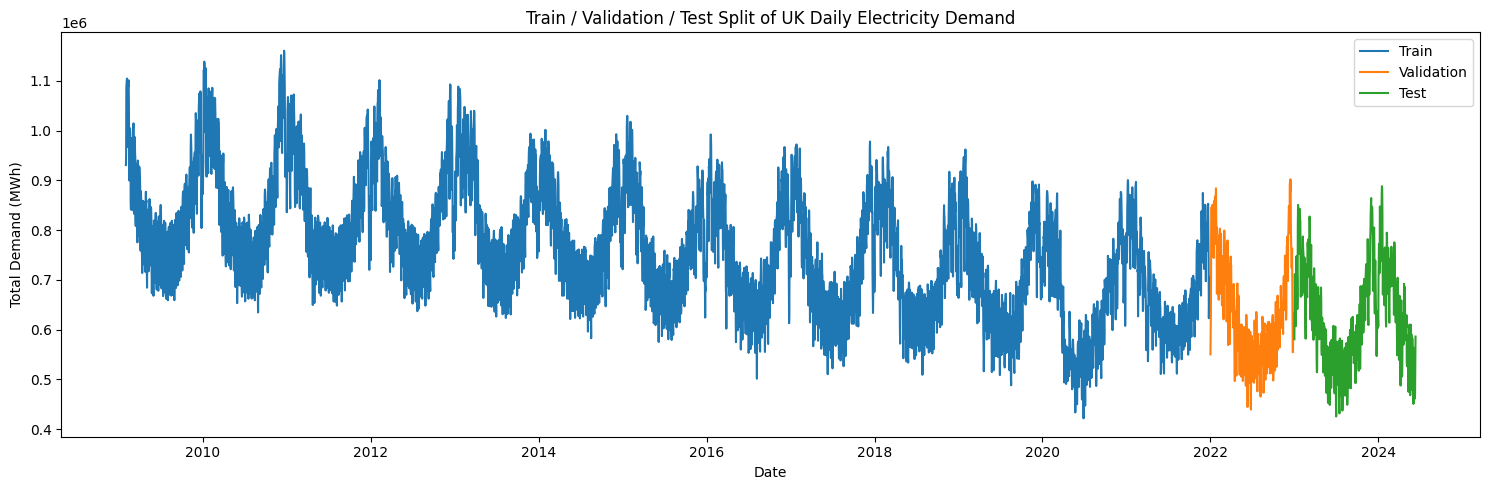


X_train: (4718, 20), X_val: (365, 20), X_test: (528, 20)

Saved split_train.csv, split_val.csv, split_test.csv


In [11]:
# Phase 8: Dataset Split (Train / Validation / Test)

import pandas as pd
import matplotlib.pyplot as plt

# 1. Define chronological split boundaries (calendar-year aligned, so each split
#    contains at least one full seasonal cycle - important given the strong annual
#    seasonality confirmed in Phase 1's STL decomposition)
train_end = '2021-12-31'
val_end = '2022-12-31'
# test runs from 2023-01-01 to the end of the dataset (2024-06-11)

train = df_model.loc[:train_end]
val = df_model.loc['2022-01-01':val_end]
test = df_model.loc['2023-01-01':]

# 2. Sanity checks: no overlap, chronological order preserved, no gaps
assert train.index.max() < val.index.min(), "Train/validation overlap detected"
assert val.index.max() < test.index.min(), "Validation/test overlap detected"

print(f"Train:      {train.index.min().date()} to {train.index.max().date()}  "
      f"({len(train)} rows, {len(train)/len(df_model)*100:.1f}%)")
print(f"Validation: {val.index.min().date()} to {val.index.max().date()}  "
      f"({len(val)} rows, {len(val)/len(df_model)*100:.1f}%)")
print(f"Test:       {test.index.min().date()} to {test.index.max().date()}  "
      f"({len(test)} rows, {len(test)/len(df_model)*100:.1f}%)")
print(f"\nTotal: {len(train) + len(val) + len(test)} (original: {len(df_model)})")

# 3. Visualize the split directly on the demand series
plt.figure(figsize=(15, 5))
plt.plot(train.index, train['nd_total_mwh'], label='Train', color='tab:blue')
plt.plot(val.index, val['nd_total_mwh'], label='Validation', color='tab:orange')
plt.plot(test.index, test['nd_total_mwh'], label='Test', color='tab:green')
plt.title('Train / Validation / Test Split of UK Daily Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Total Demand (MWh)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phase8_train_val_test_split.png', dpi=150)
plt.show()

# 4. Separate features (X) and target (y) for each split
target_col = 'nd_total_mwh'
X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_val, y_val = val.drop(columns=[target_col]), val[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

# 5. Save each split separately, ready for either model pipeline
train.to_csv(f'{LOCAL_PROCESSED_DIR}/split_train.csv')
val.to_csv(f'{LOCAL_PROCESSED_DIR}/split_val.csv')
test.to_csv(f'{LOCAL_PROCESSED_DIR}/split_test.csv')
print("\nSaved split_train.csv, split_val.csv, split_test.csv")